In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux
from few.utils.constants import Gpc, MRSUN_SI, YRSID_SI
from typing import Optional, Union, Callable
# from fastlisaresponse import ResponseWrapper
import tqdm
import os
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.fisher import StableEMRIFisher
from lisatools.sensitivity import get_sensitivity,CornishLISASens
import pandas as pd
try:
    import cupy as cp
    use_gpu = True
except ImportError:
    print("Not on GPU")
    use_gpu = False


use_gpu = False
if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info")
    force_backend = 'cpu'
else:
    force_backend = 'gpu'
    pass #let the backend decide for itself.

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,
)
##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################
from pathlib import Path

startup
Not on GPU


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
waveform_class_kwargs = dict(inspiral_kwargs=dict(err=1e-11,),
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5))

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable',
                      noise_model=get_sensitivity,
                      noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                      channels=["A","E"])

# First Analysis
We will keep these paramters constant.
  1. dist (float) – Luminosity distance in Gpc.
  2. qK - Initial BH spin polar angle in ecliptic coordinates.
  3. phiK - Initial BH spin azimuthal angle in ecliptic coordinates. - $\pi / 3$
  4. chi2 = 0.0
  5. trying phis , qs constant to see if fisher works- did not work
  6. Trying with m2 constant
  7. just normalized the last 4 params.



## Other Paramter Values Used:
1. m1 (float) – Mass of larger black hole in solar masses - 1e6
2. m2 (float) – Mass of compact object in solar masses. - 2e1
3. a (float) – Dimensionless spin of massive black hole - 0.9
4. e0: Initial eccentricity. -> 0.4
5. xI0 : Initial cosine of the inclination angle -> 1
6. dist - distance in Gpc - 0.5 Gpc
8. phi_phi0 - Initial phase for $\Phi_{\phi}$ - 0.5
9. phi_theta0 - Initial phase for $\Phi_{\theta}$ - 0.5
10. phi_r0 - Initial phase for $\Phi_{r}$ - 0.5
11. dt - 10 seconds (samplking interval)
12. T - 0.3 years (observation window)
13. deviation paramters at kept at zero; including A, B terms
14. p0 - 7
15. qS (float) – Sky location polar angle in ecliptic coordinates.
16. phiS (float) – Sky location azimuthal angle in ecliptic coordinates.


In [ ]:
m1 = 1e6
m2 = 1e1
a = 0.9
e0 = 0.4
xI0 = 1.0
dist = 0.5
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3
Phi_phi0 = 0.5
Phi_theta0 =0.5
Phi_r0 = 0.5

dt = 10.0
T = 0.3

chi2 = 0.0

A_p=0.0
B_p=0.0
A_e=0.0
B_e=0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,A_p,B_p,A_e,B_e]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

#param_names = ['m1','m2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0',"Ap","Bp","Ae","Be"] #works
#rhvae to take qK and phiK constant for it to run
#'Phi_phi0',"Phi_theta0",'Phi_r0' derivatives are present analytically it says

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"Ap":A_p,"Bp":B_p,"Ae":A_e,"Be":B_e}

emri_kwargs = {"T":T, "dt":dt}

sef.SNRcalc_SEF(*pars_list_snr,**emri_kwargs)


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1047be750>>
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniconda/base/envs/few_rishav/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.9, 7, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.5, 0.5, 0.5, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0)


np.float64(48.191641407273465)

T:  0.3 dt:  10.0
Body is not plunging, Fisher should be stable.
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.9, 7, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.5, 0.5, 0.5, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 48.191641407273465
calculating stable deltas...
Gamma_ii for m1: 83.64847558995916
Gamma_ii for m1: 83.64847558956518
Gamma_ii for m1: 83.64847558899028
Gamma_ii for m1: 83.64847558960079
Gamma_ii for m1: 83.64847558952403
Gamma_ii for m1: 83.648475585326
Gamma_ii for m1: 83.64847559241521
Gamma_ii for m1: 83.6484755851234
Gamma_ii for m1: 83.64847559236583
Gamma_ii for m1: 83.64847558917849
Gamma_ii for m1: 83.64847555604021
Gamma_ii for m1: 83.64847562352466
Gamma_ii for m1: 83.6484755986019
Gamma_ii for m1: 83.64847505578311
Gamma_ii for m1: 83.64847574729907
Gamma_ii for m1: 83.64847465262413
Gamma_ii for m1: 83.64847309201149
Gamma_ii for m1: 83.64847459145734
Gamma_ii for m1: 83.64847803271773
Ga

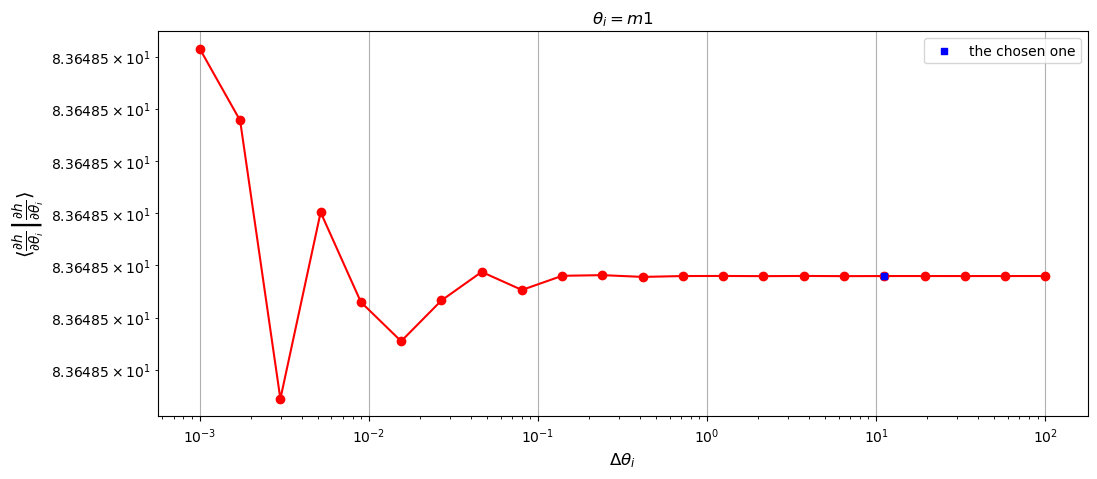

Gamma_ii for m2: 3398546454.6516185
Gamma_ii for m2: 3398546452.9942946
Gamma_ii for m2: 3398546452.019681
Gamma_ii for m2: 3398546451.4539895
Gamma_ii for m2: 3398546451.119837
Gamma_ii for m2: 3398546450.923165
Gamma_ii for m2: 3398546450.816222
Gamma_ii for m2: 3398546450.8324676
Gamma_ii for m2: 3398546450.5268297
Gamma_ii for m2: 3398546450.7082324
Gamma_ii for m2: 3398546450.3069096
Gamma_ii for m2: 3398546450.7615504
Gamma_ii for m2: 3398546450.0751143
Gamma_ii for m2: 3398546452.7453375
Gamma_ii for m2: 3398546450.515908
Gamma_ii for m2: 3398546447.2766128
Gamma_ii for m2: 3398546445.647347
Gamma_ii for m2: 3398546444.805033
Gamma_ii for m2: 3398546443.7145042
Gamma_ii for m2: 3398546457.535702
Gamma_ii for m2: 3398546571.877701
Gamma_ii for m2: 3398546526.4170003
[np.float64(4.876566674026438e-10), np.float64(2.86773678186812e-10), np.float64(1.6645100462223652e-10), np.float64(9.83222396170989e-11), np.float64(5.786943494169811e-11), np.float64(3.146717433575806e-11), np.floa

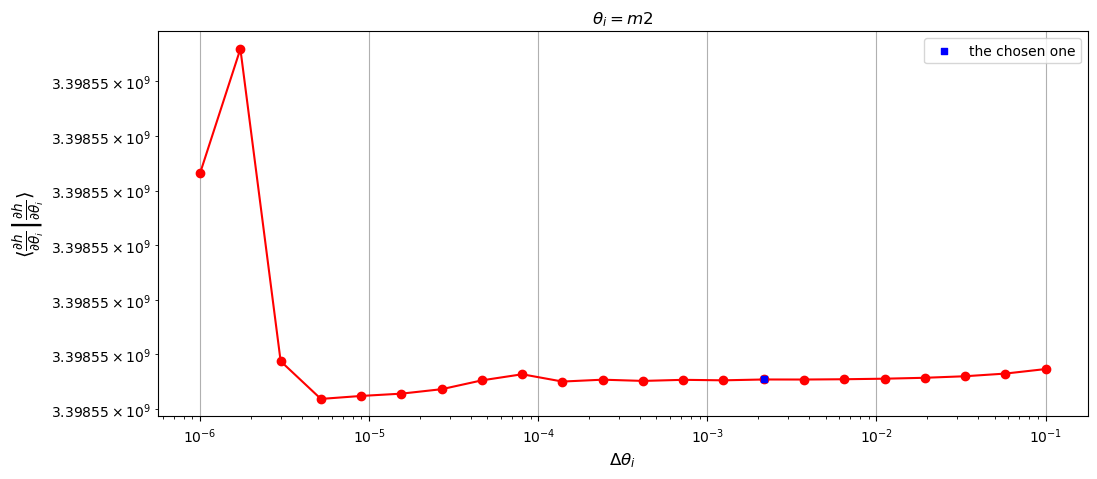

Gamma_ii for a: 244943048350.11948
Gamma_ii for a: 244943236953.74442
Gamma_ii for a: 244942829947.06052
Gamma_ii for a: 244943136649.95602
Gamma_ii for a: 244941699783.22614
Gamma_ii for a: 244951184549.7664
Gamma_ii for a: 244935226414.82938
Gamma_ii for a: 244921760792.58447
Gamma_ii for a: 244937700266.46838
Gamma_ii for a: 244940267966.25317
Gamma_ii for a: 245005353240.64227
Gamma_ii for a: 245291421899.1419
Gamma_ii for a: 244872064985.59525
Gamma_ii for a: 244882321774.0466
Gamma_ii for a: 245099012227.82095
Gamma_ii for a: 248543597671.95926
Gamma_ii for a: 245390296714.83383
Gamma_ii for a: 243529364907.56485
Gamma_ii for a: 242607170803.77255
Gamma_ii for a: 254898117395.69257
Gamma_ii for a: 243534318401.05634
Gamma_ii for a: 254454400230.93423
[np.float64(7.699891096588273e-07), np.float64(1.661639509868046e-06), np.float64(1.2521391687170083e-06), np.float64(5.866158074188861e-06), np.float64(3.8721047859744804e-05), np.float64(6.515246977984522e-05), np.float64(5.4979280

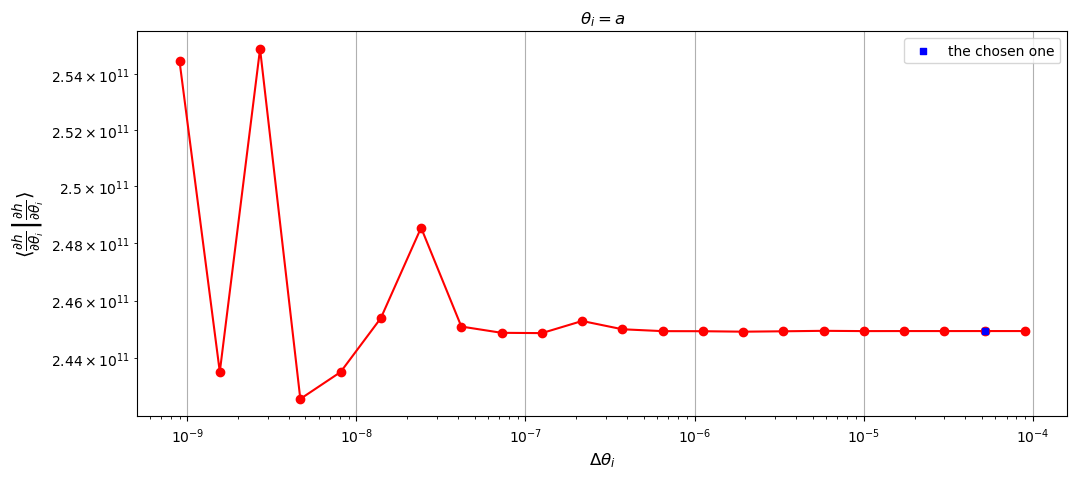

Gamma_ii for p0: 3425039889451.5474
Gamma_ii for p0: 3425039880929.1743
Gamma_ii for p0: 3425039894268.786
Gamma_ii for p0: 3425039893375.7393
Gamma_ii for p0: 3425039845148.4277
Gamma_ii for p0: 3425039939569.99
Gamma_ii for p0: 3425039770875.6973
Gamma_ii for p0: 3425039778235.268
Gamma_ii for p0: 3425039938345.6772
Gamma_ii for p0: 3425040269053.466
Gamma_ii for p0: 3425039467292.756
Gamma_ii for p0: 3425038087171.9087
Gamma_ii for p0: 3425036455112.001
Gamma_ii for p0: 3425042530716.5273
Gamma_ii for p0: 3425043588231.6807
Gamma_ii for p0: 3425024895008.6167
Gamma_ii for p0: 3425025473184.309
Gamma_ii for p0: 3425090224920.9683
Gamma_ii for p0: 3425003000185.2036
Gamma_ii for p0: 3424689004487.9497
Gamma_ii for p0: 3425341325864.9287
Gamma_ii for p0: 3424779321180.042
[np.float64(2.488255127868169e-09), np.float64(3.894731806986479e-09), np.float64(2.607405761104312e-10), np.float64(1.4080803057445166e-08), np.float64(2.756801794020963e-08), np.float64(4.9253236240704754e-08), np.f

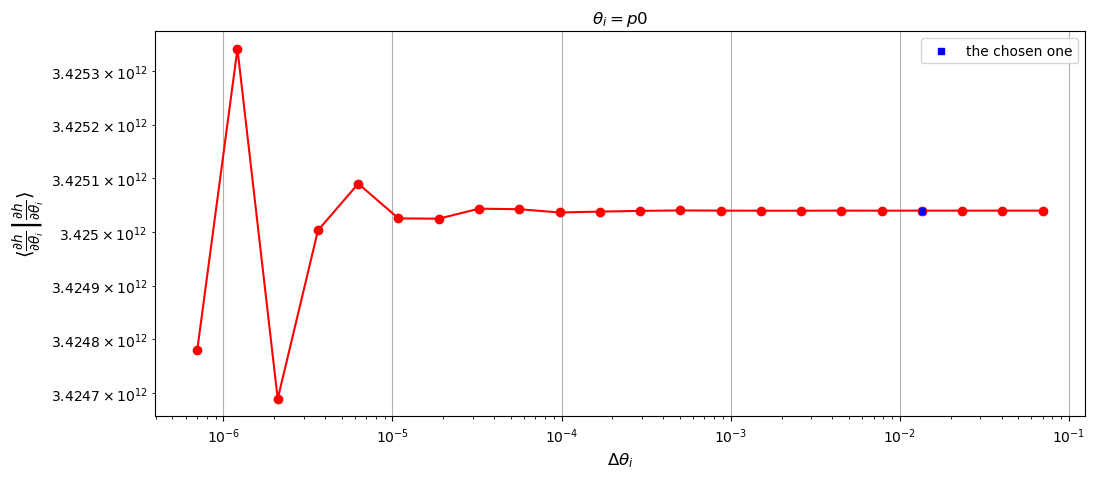

Gamma_ii for e0: 64364840205240.66
Gamma_ii for e0: 64364839246811.22
Gamma_ii for e0: 64364839116376.63
Gamma_ii for e0: 64364839090001.67
Gamma_ii for e0: 64364839179662.57
Gamma_ii for e0: 64364839025384.38
Gamma_ii for e0: 64364842903389.89
Gamma_ii for e0: 64364837921304.97
Gamma_ii for e0: 64364853111101.27
Gamma_ii for e0: 64364855395798.0
Gamma_ii for e0: 64364863680428.94
Gamma_ii for e0: 64364801097572.375
Gamma_ii for e0: 64364743011296.484
Gamma_ii for e0: 64364653358153.86
Gamma_ii for e0: 64364440260818.0
Gamma_ii for e0: 64366471488298.27
Gamma_ii for e0: 64364445910477.95
Gamma_ii for e0: 64366375349997.05
Gamma_ii for e0: 64361308564366.65
Gamma_ii for e0: 64365258863789.22
Gamma_ii for e0: 64386489350660.66
Gamma_ii for e0: 64366466650185.73
[np.float64(1.4890574554607977e-08), np.float64(2.0264881840481903e-09), np.float64(4.097728093535628e-10), np.float64(1.3930105253153534e-09), np.float64(2.3969327017062117e-09), np.float64(6.025036856896078e-08), np.float64(7.74

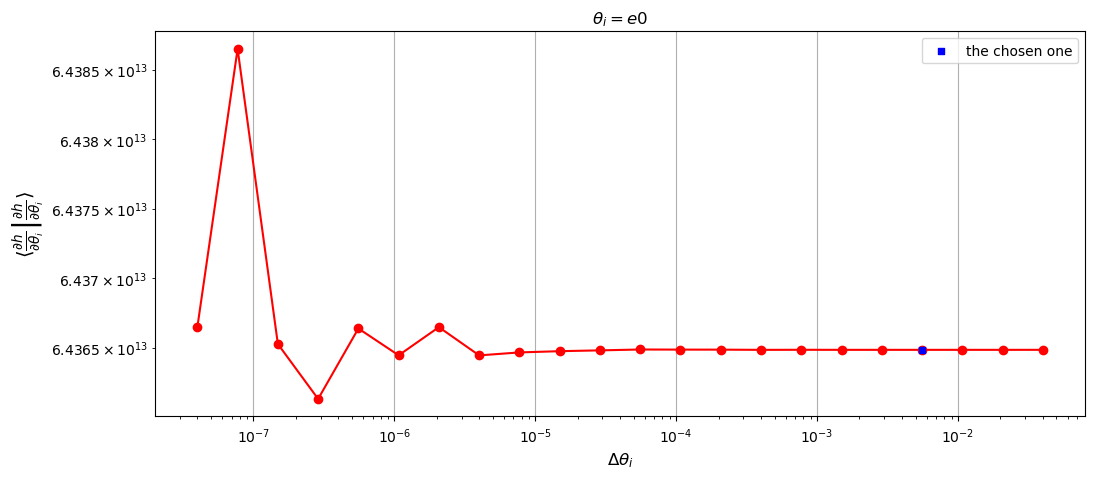

Gamma_ii for qS: 7127.503574616991
Gamma_ii for qS: 7127.503583498434
Gamma_ii for qS: 7127.503583610582
Gamma_ii for qS: 7127.503583612005
Gamma_ii for qS: 7127.503583611927
Gamma_ii for qS: 7127.50358361201
Gamma_ii for qS: 7127.503583611965
Gamma_ii for qS: 7127.503583612263
Gamma_ii for qS: 7127.503583611915
Gamma_ii for qS: 7127.503583612644
Gamma_ii for qS: 7127.503583612351
Gamma_ii for qS: 7127.50358361131
Gamma_ii for qS: 7127.503583610777
Gamma_ii for qS: 7127.503583615896
Gamma_ii for qS: 7127.503583596984
Gamma_ii for qS: 7127.503583591439
Gamma_ii for qS: 7127.503583613213
Gamma_ii for qS: 7127.503583641408
Gamma_ii for qS: 7127.503583635219
Gamma_ii for qS: 7127.503583656326
Gamma_ii for qS: 7127.503583913596
Gamma_ii for qS: 7127.503583671424
[np.float64(1.2460804870095566e-09), np.float64(1.5734537537672538e-11), np.float64(1.996995429854722e-13), np.float64(1.097390459856281e-14), np.float64(1.1611922307781442e-14), np.float64(6.252573550343893e-15), np.float64(4.18539

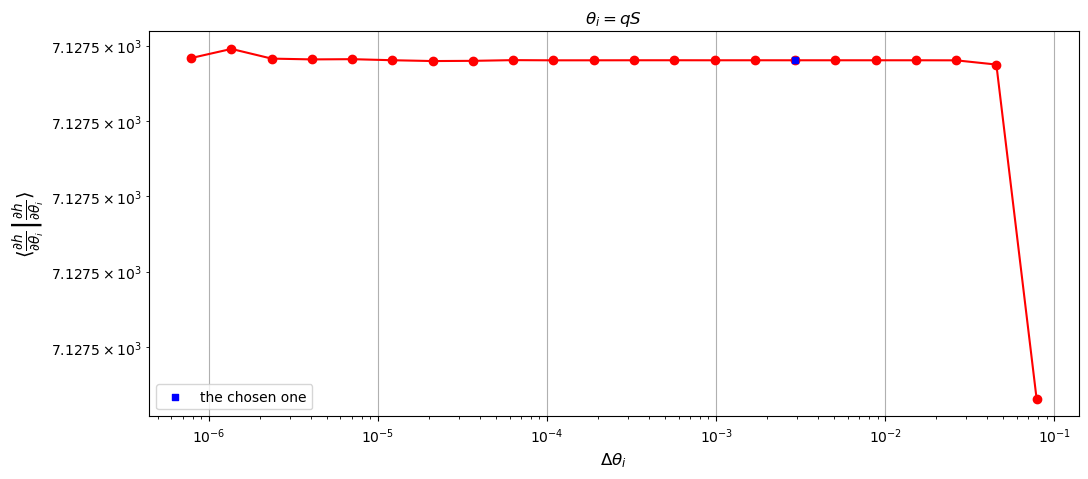

Gamma_ii for phiS: 137635.1264175343
Gamma_ii for phiS: 137635.12641753434
Gamma_ii for phiS: 137635.1264175343
Gamma_ii for phiS: 137635.12641753443
Gamma_ii for phiS: 137635.12641753425
Gamma_ii for phiS: 137635.12641753405
Gamma_ii for phiS: 137635.1264175349
Gamma_ii for phiS: 137635.12641753245
Gamma_ii for phiS: 137635.12641753504
Gamma_ii for phiS: 137635.126417548
Gamma_ii for phiS: 137635.12641752907
Gamma_ii for phiS: 137635.12641750186
Gamma_ii for phiS: 137635.1264175272
Gamma_ii for phiS: 137635.1264174841
Gamma_ii for phiS: 137635.1264176422
Gamma_ii for phiS: 137635.12641785506
Gamma_ii for phiS: 137635.12641774712
Gamma_ii for phiS: 137635.12641818784
Gamma_ii for phiS: 137635.12641640828
Gamma_ii for phiS: 137635.12641886636
Gamma_ii for phiS: 137635.1264207038
Gamma_ii for phiS: 137635.12640634022
[np.float64(2.1145641533719662e-16), np.float64(2.1145641533719666e-16), np.float64(8.45825661348786e-16), np.float64(1.2687384920231806e-15), np.float64(1.4801949073603795e

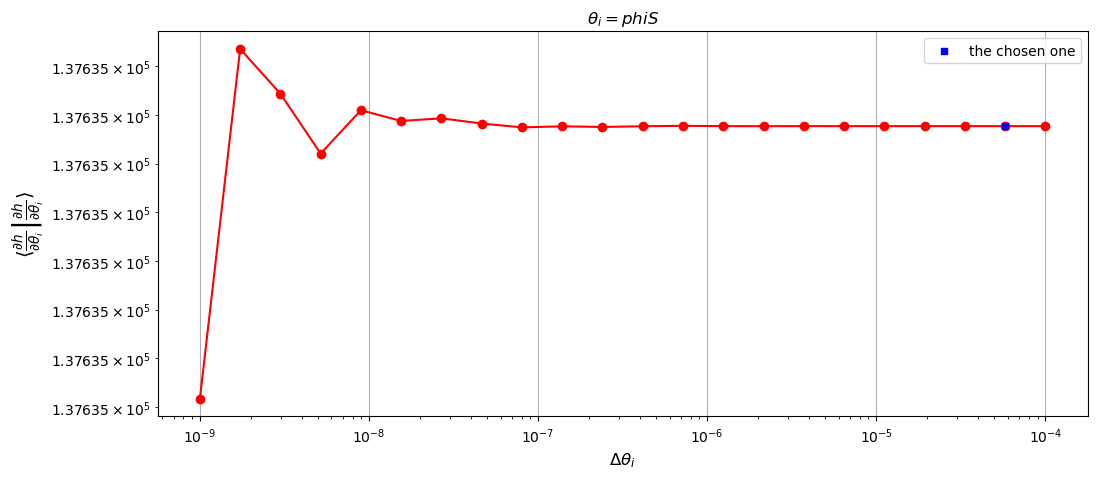

Gamma_ii for Ap: 1.2886874015265235e-05
Gamma_ii for Ap: 1.2887136102785618e-05
Gamma_ii for Ap: 1.2886722736911803e-05
Gamma_ii for Ap: 1.2887400682912914e-05
Gamma_ii for Ap: 1.2883618448684325e-05
Gamma_ii for Ap: 1.2890074477158948e-05
Gamma_ii for Ap: 1.285528330886216e-05
Gamma_ii for Ap: 1.298998291713453e-05
Gamma_ii for Ap: 1.3275236369132027e-05
Gamma_ii for Ap: 1.3472431488219231e-05
Gamma_ii for Ap: 1.2823251435298013e-05
Gamma_ii for Ap: 1.1303365473375889e-05
Gamma_ii for Ap: 1.0077242192794176e-05
Gamma_ii for Ap: 1.2993535118701345e-05
Gamma_ii for Ap: 0.0002491364997108432
Gamma_ii for Ap: 0.00020730659912013993
Gamma_ii for Ap: 0.002728306579364175
Gamma_ii for Ap: 0.033544387903811715
Gamma_ii for Ap: 0.044937610425740966
Gamma_ii for Ap: 1.6174083855190902
Gamma_ii for Ap: 48.22844553778842
Gamma_ii for Ap: 21.959162711097886
[np.float64(2.0337142270554067e-05), np.float64(3.207688116316371e-05), np.float64(5.2605332742500086e-05), np.float64(0.00029356925181020103)

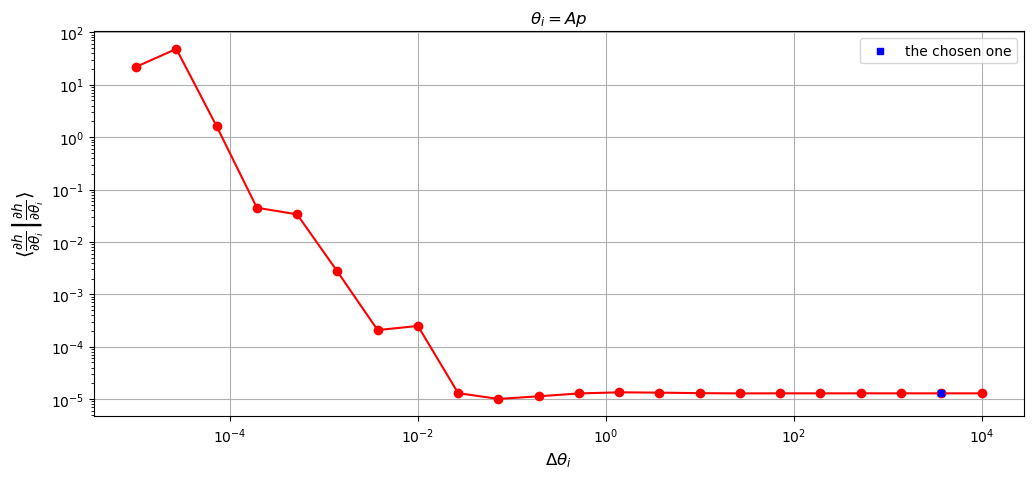

Gamma_ii for Bp: 2.8309107787077694e-07
Gamma_ii for Bp: 2.8305211117632787e-07
Gamma_ii for Bp: 2.8306948666267077e-07
Gamma_ii for Bp: 2.829997819391462e-07
Gamma_ii for Bp: 2.8302004878252204e-07
Gamma_ii for Bp: 2.8462570027364754e-07
Gamma_ii for Bp: 2.821416389713826e-07
Gamma_ii for Bp: 2.840632993094924e-07
Gamma_ii for Bp: 3.069271407410388e-07
Gamma_ii for Bp: 2.5712844850999066e-07
Gamma_ii for Bp: 1.8650217041772125e-07
Gamma_ii for Bp: 4.372959198836463e-07
Gamma_ii for Bp: 1.8059139164317384e-06
Gamma_ii for Bp: 1.4853924328140195e-05
Gamma_ii for Bp: 0.00022736406204404617
Gamma_ii for Bp: 0.0004675693433787874
Gamma_ii for Bp: 0.0007896867755911362
Gamma_ii for Bp: 0.00846560191170432
Gamma_ii for Bp: 0.013377543819300706
Gamma_ii for Bp: 1.6693650463218892
Gamma_ii for Bp: 41.80780984543146
Gamma_ii for Bp: 2.9723190746009673
[np.float64(0.00013766615019095664), np.float64(6.138240665834039e-05), np.float64(0.000246306633337026), np.float64(7.160921448142612e-05), np.f

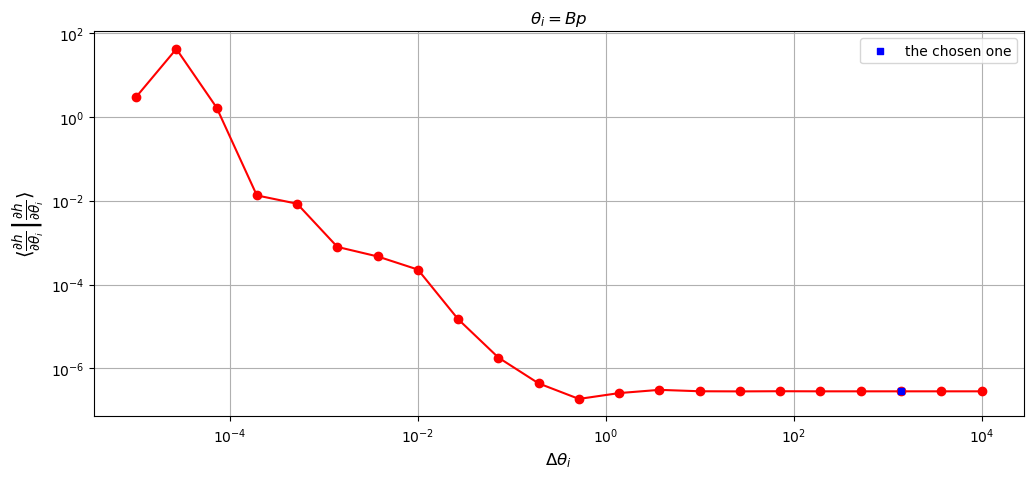

Gamma_ii for Ae: 5.002676802682959e-06
Gamma_ii for Ae: 5.002669843122099e-06
Gamma_ii for Ae: 5.002511978658507e-06
Gamma_ii for Ae: 5.002218890222259e-06
Gamma_ii for Ae: 5.0008708634842425e-06
Gamma_ii for Ae: 4.99077496706605e-06
Gamma_ii for Ae: 5.015783503914801e-06
Gamma_ii for Ae: 5.010160358470217e-06
Gamma_ii for Ae: 5.088817889820229e-06
Gamma_ii for Ae: 5.136065648404625e-06
Gamma_ii for Ae: 4.700819563209788e-06
Gamma_ii for Ae: 4.945683723378035e-06
Gamma_ii for Ae: 4.731610886172537e-06
Gamma_ii for Ae: 2.1406521558166577e-05
Gamma_ii for Ae: 3.3589148996679543e-05
Gamma_ii for Ae: 0.00010246560037791537
Gamma_ii for Ae: 0.0013029883896318278
Gamma_ii for Ae: 0.108177933827656
Gamma_ii for Ae: 0.0830213852073053
Gamma_ii for Ae: 0.27548904945464076
Gamma_ii for Ae: 27.210339821204435
Gamma_ii for Ae: 20.88269593758662
[np.float64(1.391169331193893e-06), np.float64(3.155703859694373e-05), np.float64(5.859168554604212e-05), np.float64(0.0002695583978901297), np.float64(0.0

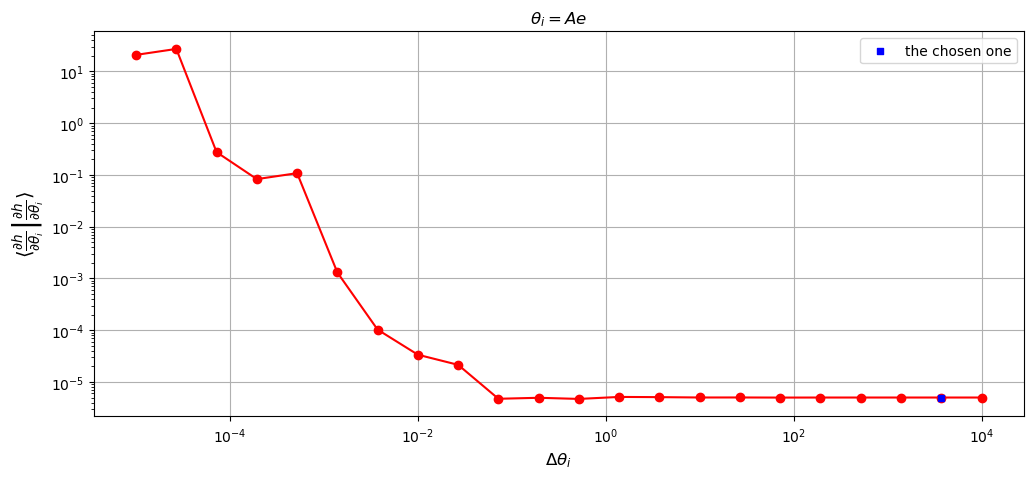

Gamma_ii for Be: 1.0981893323428266e-07
Gamma_ii for Be: 1.0982718948119933e-07
Gamma_ii for Be: 1.0983776581662915e-07
Gamma_ii for Be: 1.0987321267602362e-07
Gamma_ii for Be: 1.0921415176178827e-07
Gamma_ii for Be: 1.1041004627404855e-07
Gamma_ii for Be: 1.0861205102294176e-07
Gamma_ii for Be: 1.1154601234148167e-07
Gamma_ii for Be: 1.3861183121124143e-07
Gamma_ii for Be: 1.1421590397589511e-07
Gamma_ii for Be: 1.0940658052021047e-07
Gamma_ii for Be: 4.3566104189656615e-07
Gamma_ii for Be: 7.324232683142233e-07
Gamma_ii for Be: 5.623592684170782e-05
Gamma_ii for Be: 2.1572777442537508e-05
Gamma_ii for Be: 0.00026905741838805305
Gamma_ii for Be: 0.02524892527342048
Gamma_ii for Be: 0.017582177973371478
Gamma_ii for Be: 0.45348529230655193
Gamma_ii for Be: 2.088932792052139
Gamma_ii for Be: 0.8531309611822449
Gamma_ii for Be: 7.993697442328137
[np.float64(7.517489025866405e-05), np.float64(9.629051857699118e-05), np.float64(0.00032261602742963237), np.float64(0.006034574307484027), np.

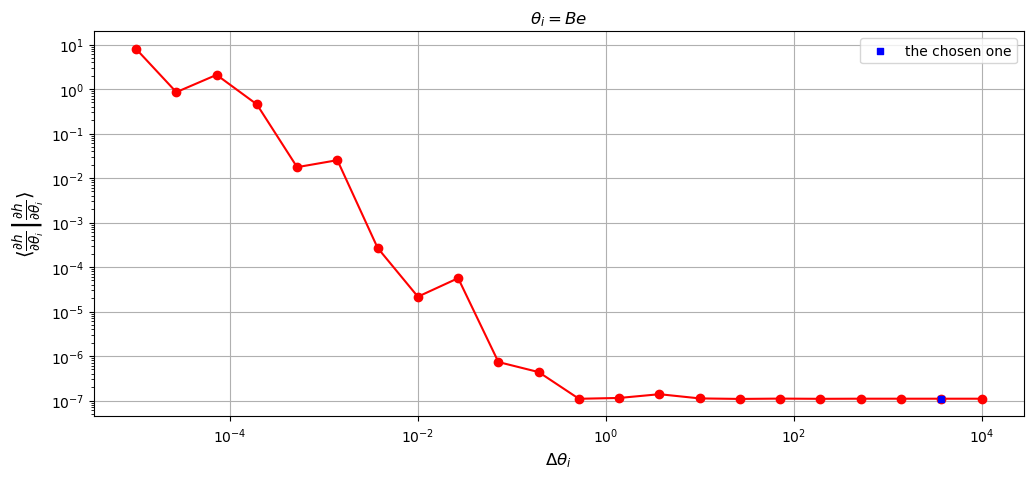

stable deltas: {'m1': 11.158839925077485, 'm2': 0.0021544346900318843, 'a': 5.2017235957379856e-05, 'p0': 0.013514884102182757, 'e0': 0.005557981977492551, 'qS': 0.002927645261827215, 'phiS': 5.7796928841533134e-05, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'Ap': 3727.593720314942, 'Bp': 1389.4954943731375, 'Ae': 3727.593720314942, 'Be': 3727.593720314942}
Time taken to compute stable deltas is 506.2518630027771 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is not positive semi-definite. Try lowering inspiral error tolerance or increasing the derivative order.
Time taken to compute FM is 41.271286964416504 seconds


In [ ]:
der_order = 8
Ndelta = 22
stability_plot = True

delta_range = dict(
    m1 = np.geomspace(1e-4*m1, 1e-9*m1, Ndelta),
    m2 = np.geomspace(1e-2*m2, 1e-7*m2, Ndelta),
    p0 = np.geomspace(1e-2*p0, 1e-7*p0, Ndelta),
    e0 = np.geomspace(1e-1*e0, 1e-7*e0, Ndelta),
    phiK = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiS = np.geomspace(1e-4,    1e-9,    Ndelta),
    Phi_r0 = np.geomspace(1e-4,    1e-9,    Ndelta),
    Phi_phi0 = np.geomspace(1e-4,    1e-9,    Ndelta),
    Ap = np.geomspace(1e4,    1e-5,    Ndelta),
    Bp = np.geomspace(1e4,    1e-5,    Ndelta),
    Ae = np.geomspace(1e4,    1e-5,    Ndelta),
    Be = np.geomspace(1e4,    1e-5,    Ndelta)
)

Fisher = sef(*pars_list,param_names = param_names,T = T, dt = dt, add_param_args=add_param_args,\
             der_order = der_order, Ndelta = Ndelta, stability_plot = stability_plot,
            delta_range = delta_range,
            live_dangerously = False)

In [44]:
# part of code written by geminine to check positive definiteness
def is_positive_definite_eigenvalues(matrix):
    if not np.allclose(matrix, matrix.T):  # Check for symmetry
        return False
    eigenvalues = np.linalg.eigvals(matrix)
    return np.all(eigenvalues > 0)
pd.DataFrame(Fisher) 


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,8.364848e+01,-5.179348e+05,1.909219e+06,1.691326e+07,7.324364e+07,-6.237921e+02,2.877943e+03,-7.544504e+02,-6.841739e+02,0.031696,4.712086e-03,1.997725e-02,2.968083e-03
1,-5.179348e+05,3.398546e+09,-1.472137e+10,-1.051984e+11,-4.468485e+11,3.477150e+06,-1.604133e+07,4.205323e+06,3.658645e+06,-209.198785,-3.101207e+01,-1.302843e+02,-1.929557e+01
2,1.909219e+06,-1.472137e+10,2.449432e+11,4.186154e+11,1.572426e+12,-1.537367e+07,7.103398e+07,-1.866641e+07,1.758392e+06,932.570966,1.375526e+02,5.297269e+02,7.796702e+01
3,1.691326e+07,-1.051984e+11,4.186154e+11,3.425040e+12,1.479319e+13,-1.262934e+08,5.826872e+08,-1.527583e+08,-1.354997e+08,6442.908061,9.576632e+02,4.051447e+03,6.018156e+02
4,7.324364e+07,-4.468485e+11,1.572426e+12,1.479319e+13,6.436484e+13,-5.597757e+08,2.582615e+09,-6.770272e+08,-6.193860e+08,27303.704774,4.062188e+03,1.726264e+04,2.566879e+03
5,-6.237921e+02,3.477150e+06,-1.537367e+07,-1.262934e+08,-5.597757e+08,7.127504e+03,-2.973384e+04,7.795919e+03,6.630497e+03,-0.211457,-3.157834e-02,-1.343249e-01,-2.005764e-02
6,2.877943e+03,-1.604133e+07,7.103398e+07,5.826872e+08,2.582615e+09,-2.973384e+04,1.376351e+05,-3.597707e+04,-3.058509e+04,0.975559,1.456874e-01,6.196901e-01,9.253352e-02
7,-7.544504e+02,4.205323e+06,-1.866641e+07,-1.527583e+08,-6.770272e+08,7.795919e+03,-3.597707e+04,9.433901e+03,8.014557e+03,-0.255752,-3.819334e-02,-1.624482e-01,-2.425715e-02
8,-6.841739e+02,3.658645e+06,1.758392e+06,-1.354997e+08,-6.193860e+08,6.630497e+03,-3.058509e+04,8.014557e+03,9.239376e+03,-0.220428,-3.295792e-02,-1.442714e-01,-2.156943e-02
9,3.169580e-02,-2.091988e+02,9.325710e+02,6.442908e+03,2.730370e+04,-2.114568e-01,9.755592e-01,-2.557519e-01,-2.204277e-01,0.000013,1.909803e-06,8.011786e-06,1.186157e-06


In [56]:
#from stableemrifisher.utils import fishinv
J = np.eye(len(Fisher))
J[0,0] = m1
J[9,9] = 1e8
J[10,10] = 1e8
J[11,11] = 1e8
J[12,12] = 1e8
Fisher_J = J.T @ Fisher @ J
# Fisher_lnM_inv = np.linalg.inv(Fisher_lnM)
# Fisher_inv = J.T @ Fisher_lnM_inv @ J
pd.DataFrame(Fisher_J) 
np.linalg.cond(Fisher_J)
Fisher_J_inv = np.linalg.inv(Fisher_J)

print(is_positive_definite_eigenvalues(Fisher_J))
pd.DataFrame(np.matmul(Fisher_J,Fisher_J_inv))


True


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.000053e+00,-1.669082e-05,2.755194e-05,-8.392285e-05,4.141671e-08,2.672831e-07,-1.206841e-07,1.390847e-05,-1.144960e-05,4.449610e-07,-5.445090e-04,-2.914792e-05,-3.327251e-04
1,-7.426448e-08,9.999977e-01,-3.191982e-07,9.428653e-07,-2.232143e-10,2.855011e-08,7.801669e-10,1.013268e-07,1.000252e-07,-9.502390e-09,-7.958455e-07,-7.321147e-08,-3.636922e-06
2,1.262109e-06,9.078572e-06,1.000002e+00,6.353280e-07,8.821623e-09,6.377170e-08,1.801041e-08,2.895211e-07,-3.231164e-07,3.335434e-08,-9.047794e-06,3.485771e-06,4.562699e-06
3,3.404570e-06,1.361245e-05,9.094679e-06,9.999877e-01,1.754755e-08,-1.949537e-07,1.126358e-07,7.849167e-06,-9.804906e-06,3.828947e-07,4.595175e-05,-3.615324e-06,3.388714e-05
4,3.468143e-05,4.339027e-04,3.164262e-05,5.094609e-05,1.000000e+00,-7.841316e-07,1.274348e-07,-1.408725e-05,8.613230e-06,2.691087e-06,8.566391e-05,4.249109e-05,2.817842e-04
5,-4.626092e-10,-1.929040e-09,-8.402545e-10,1.348373e-09,-2.489180e-13,1.000000e+00,9.170357e-12,5.015728e-12,1.742917e-10,-1.908568e-11,-2.896562e-10,-2.096947e-09,-1.169381e-09
6,1.115102e-09,7.743042e-09,3.152115e-10,-3.451572e-09,1.040638e-11,-4.292779e-11,1.000000e+00,-3.033715e-10,-7.889477e-10,1.460585e-10,9.029857e-09,2.937330e-09,9.899756e-09
7,-1.026386e-09,-8.003565e-10,-1.034399e-09,6.595869e-10,-1.289429e-12,1.705575e-11,6.288239e-13,1.000000e+00,5.267284e-11,-2.792825e-11,3.955122e-09,1.584466e-10,-3.774018e-09
8,-3.143846e-10,-6.847100e-10,-3.976944e-10,1.017998e-09,6.522460e-13,3.278888e-11,2.623089e-11,-1.101703e-10,1.000000e+00,-1.283423e-11,5.108060e-10,-1.648364e-09,2.979701e-09
9,1.501720e-06,4.927678e-06,2.137960e-06,-5.815921e-07,-8.082803e-09,-1.095438e-07,-4.381081e-08,-2.668540e-07,-1.131514e-06,1.000000e+00,-8.583306e-06,8.834734e-06,-6.343126e-08


In [58]:
print(np.linalg.cond(Fisher_J))
np.sum(np.matmul(Fisher_J,Fisher_J_inv))

150764904752247.4


np.float64(13.000110678773757)

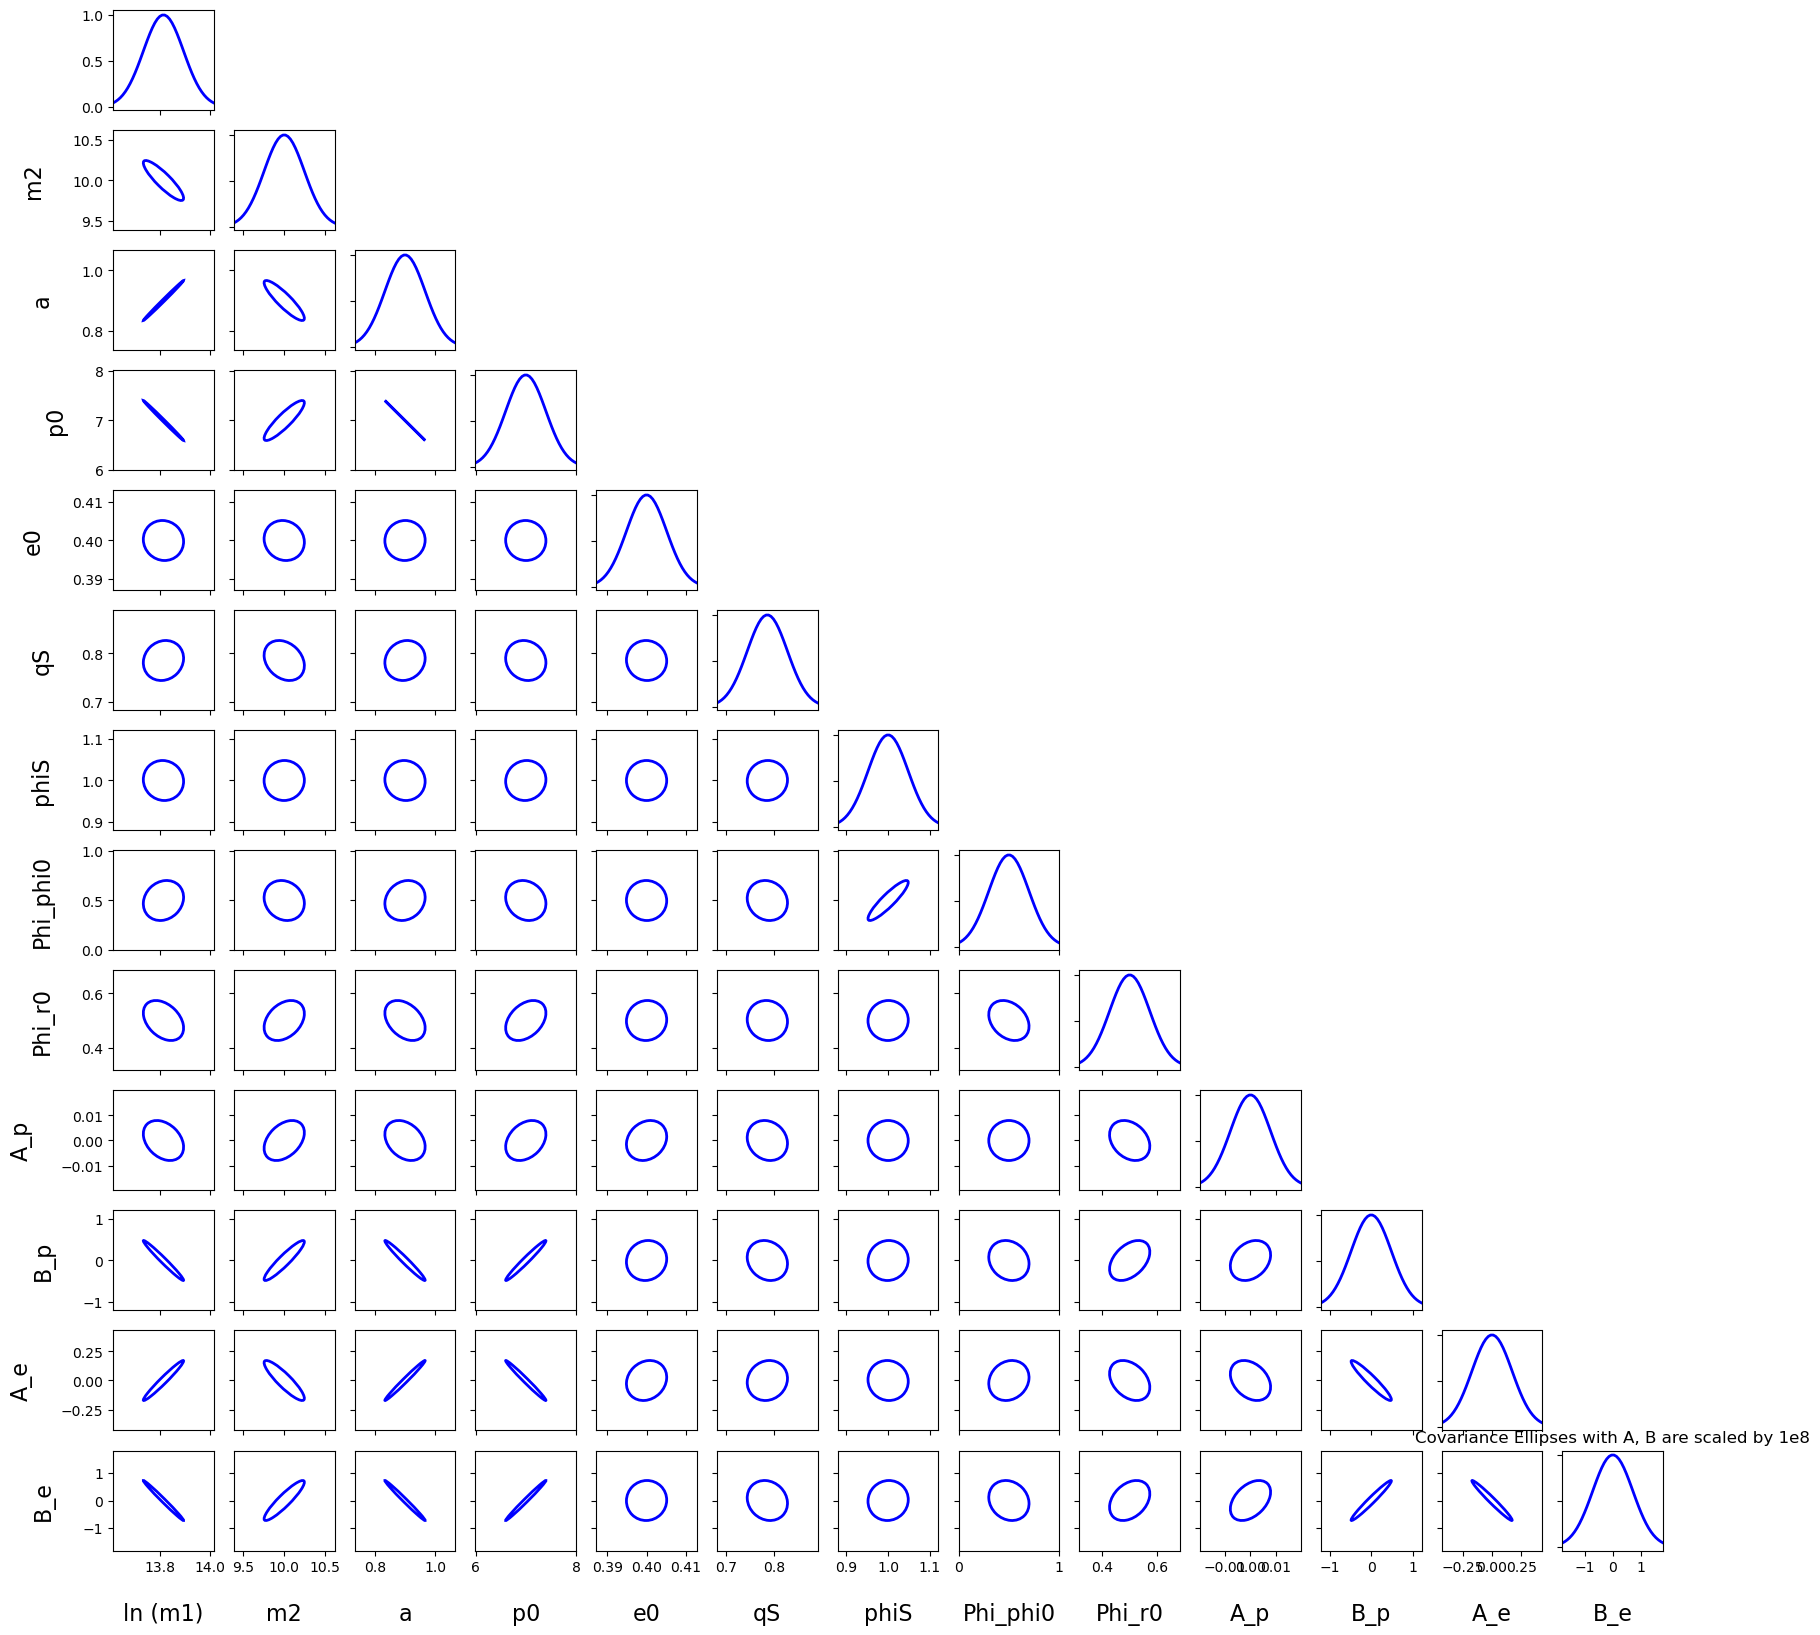

In [60]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = [np.log(m1),m2, a,p0, e0,qS,phiS,Phi_phi0,Phi_r0,A_p,B_p,A_e,B_e]
param_names = param_names = ["ln (m1)",'m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0',"A_p","B_p","A_e","B_e"] 
wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = pars_list[i]
    
param_names = param_names

covariance = Fisher_J_inv

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
plt.title("Covariance Ellipses with A, B are scaled by 1e8")

fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)



In [62]:
pd.DataFrame(covariance).to_csv(
    "../covariance_devpn_1_6_dev.csv",
    float_format="%.3f"
)


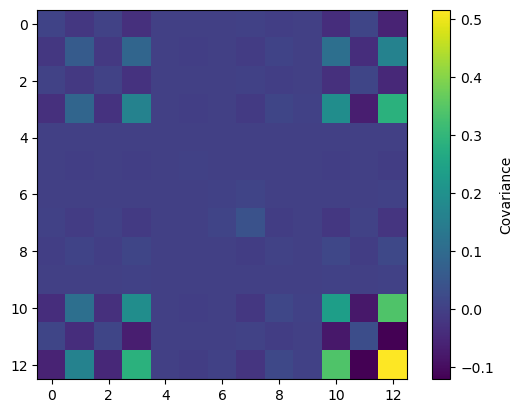

In [61]:
plt.imshow(covariance[0:][0:], cmap='viridis', interpolation='nearest')
plt.colorbar(label='Covariance')

In [ ]:
# import numpy
# Covariance_fisher_2th_order_dev_param_unnormalized=np.loadtxt("../../Results/Covariance_fisher_2th_order_dev_param_unnormalized_no_chi.txt")
# Covariance_fisher_2th_order_dev_param_normalized=np.loadtxt("../../Results/Covariance_fisher_2th_order_dev_param_normalized_no_chi.txt")

In [63]:
import matplotlib.pyplot as plt
from stableemrifisher.plot import CovEllipsePlot
dev_0_p, dev_0_e, dev_1_p, dev_1_e=0.0,0.0,0.0,0.0
Covariance_fisher_dev_a=np.loadtxt("../covariance_dev0p_dev0e_normalized_both.csv")
Covariance_fisher_dev_b=np.loadtxt("../covariance_dev1p_dev1e_normalized_both.csv")
# Parameters
pars_list = [np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e, dev_1_p, dev_1_e]
param_names = ['ln (m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0',"dev_0_p","dev_0_e","dev_1_p","dev_1_e"]

wave_params = {param_names[i]: pars_list[i] for i in range(len(pars_list))}

ellipse_kwargs_unnorm = dict(facecolor='none', edgecolor='tab:blue', lw=2, label='dev_a (0th order)')
line_kwargs_unnorm = dict(lw=2, color='tab:blue')

ellipse_kwargs_norm = dict(facecolor='none', edgecolor='tab:orange', lw=2, label='dev_b (1st order)')
line_kwargs_norm = dict(lw=2, color='tab:orange')

n_params = len(param_names)
fig, axs = plt.subplots(n_params, n_params, figsize=(22, 22))

fig, axs = CovEllipsePlot(
    Covariance_fisher_dev_a,
    wave_params=wave_params,
    param_names=param_names,
    fig=fig,
    axs=axs,
    ellipse_kwargs=ellipse_kwargs_unnorm,
    line_kwargs=line_kwargs_unnorm
)

fig, axs = CovEllipsePlot(
    Covariance_fisher_dev_b,
    wave_params=wave_params,
    param_names=param_names,
    fig=fig,
    axs=axs,
    ellipse_kwargs=ellipse_kwargs_norm,
    line_kwargs=line_kwargs_norm
)

fig.suptitle("Covariance Ellipse Comparison: 0th order vs 1st order", fontsize=22, y=0.93)

for i in range(n_params):
    for j in range(n_params):
        axs[i, j].grid(True, linestyle='--', alpha=0.3)
        if i < n_params - 1:
            axs[i, j].set_xlabel('')
        if j > 0:
            axs[i, j].set_ylabel('')

for i, name in enumerate(param_names):
    axs[-1, i].set_xlabel(name, fontsize=13)
    axs[i, 0].set_ylabel(name, fontsize=13)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='tab:blue', lw=3, label='Unnormalized covariance'),
    Line2D([0], [0], color='tab:orange', lw=3, label='Normalized covariance')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.98, 0.98)
)

plt.tight_layout(rect=[0, 0, 0.96, 0.95])
plt.show()


ValueError: could not convert string ',0,1,2,3,4,5,6,7,8,9,10' to float64 at row 0, column 1.